<a href="https://colab.research.google.com/github/SanjaraT/PyTorch-from-beginning/blob/main/vgg16_fmnist_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [6]:
df = pd.read_csv("/content/drive/MyDrive/fashion_mnist-dataset/fashion-mnist_train.csv")

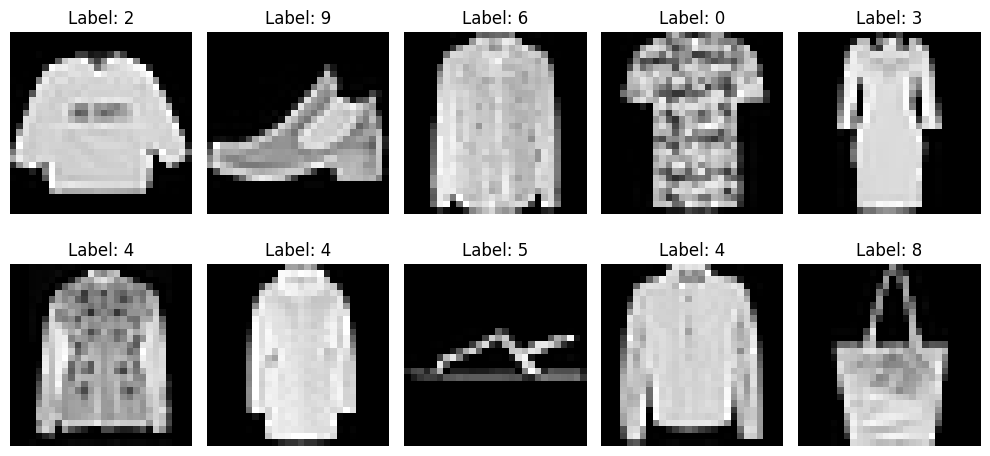

In [7]:
# Data Visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {df.iloc[i, 0]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Data Split
X = df.drop('label', axis=1).values
y = df['label'].values

In [9]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# transformation
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
# dataset class

from PIL import Image
class CustomDataset(Dataset):
  def __init__(self, features, labels, transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):

    # resizing
    img = self.features[index].reshape(28,28)

    # converting datatype
    img = img.astype(np.uint8)

    # one to three channels
    img = np.stack([img]*3, axis = -1)

    # array --> PIL images
    img = Image.fromarray(img)

    # applying transformations
    img = self.transform(img)

    return img, torch.tensor(self.labels[index], dtype=torch.long)

In [13]:
# Class object
train_dataset = CustomDataset(X_train, y_train, transform=custom_transform)
test_dataset = CustomDataset(X_test, y_test, transform=custom_transform)

In [14]:
# Dataloader object
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)